# Test Tanzanian ALPR

Run the trained plate detector + OCR on a photo. Change `IMAGE` in the next cell, or leave it to pick a labelled example.

Select kernel **tz-alpr (.venv)** — the existing project env. Do not click *Create a Python Environment*.

In [8]:
from __future__ import annotations

import json
import os
import random
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

REPO = Path("..").resolve()
if not (REPO / "src" / "tz_alpr").exists():
    REPO = Path.cwd()
os.chdir(REPO)
sys.path.insert(0, str(REPO / "src"))

os.environ.setdefault("TZ_ALPR_DEVICE", "cuda:0")
os.environ.setdefault("TZ_ALPR_RUNTIME", "torch")
os.environ.setdefault("TZ_ALPR_OCR_WEIGHTS", "models/ocr/v1/ocr_crnn.pt")
os.environ.setdefault("TZ_ALPR_PLATE_DETECTOR_WEIGHTS", "models/plate_detector/v1/plate_yolo.pt")

# Set to a path, or None to use the labelled T336CAG example.
IMAGE: Path | None = None

images_dir = REPO / "labeled_images"
if IMAGE is None:
    matches = sorted(images_dir.glob("T336DHU-*.jpg"))
    IMAGE = matches[0] if matches else next(images_dir.glob("*.jpg"))

print("repo   ", REPO)
print("image  ", IMAGE)

repo    /home/tamisemi/plates/tz-plates
image   /home/tamisemi/plates/tz-plates/labeled_images/T336DHU-85726f7d377311ee9793e563e76c00f6.jpg


In [9]:
from tz_alpr.pipeline import get_pipeline
from tz_alpr.utils.image_io import imread

pipeline = get_pipeline("configs/inference.yaml")
print("ocr    ", pipeline._ocr.backend)
print("plate  ", pipeline._plate_detector.name)
print("vehicle", pipeline._vehicle_detector.name if pipeline._vehicle_detector else None)

ocr     torch
plate   yolo
vehicle yolo


{
  "processing_time_ms": 63,
  "model_version": "tz-alpr-1.2.0",
  "results": [
    {
      "plate": "T336DHU",
      "raw_text": "T 336 DHU",
      "raw_ocr": "T336DHU",
      "normalized_text": "T336DHU",
      "confidence": 0.8941,
      "confidence_breakdown": {
        "vehicle_confidence": 0.0,
        "plate_detection_confidence": 0.7635,
        "ocr_confidence": 0.9347,
        "plate_validation_confidence": 0.92,
        "final_confidence": 0.8941
      },
      "plate_bbox": {
        "x": 347,
        "y": 736,
        "width": 532,
        "height": 244
      },
      "plate_bbox_in_vehicle": null,
      "plate_quad": null,
      "vehicle": {
        "type": "unknown",
        "confidence": 0.0,
        "bbox": null
      },
      "vehicle_track_id": null,
      "country": "TZ",
      "plate_type": "PRIVATE",
      "plate_colour": "yellow",
      "plate_lines": 2,
      "corrections": [],
      "ocr_candidates": [
        {
          "text": "T336DHU",
          "confiden

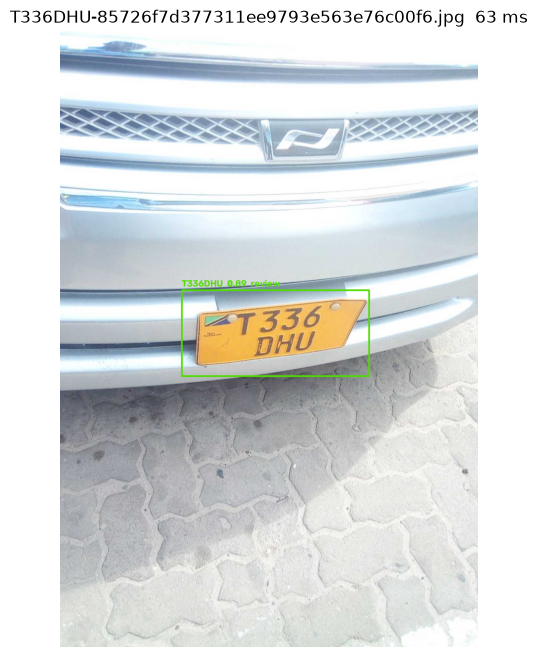

In [10]:
def annotate(image_bgr: np.ndarray, response) -> np.ndarray:
    vis = image_bgr.copy()
    for r in response.results:
        x, y, w, h = r.plate_bbox.x, r.plate_bbox.y, r.plate_bbox.width, r.plate_bbox.height
        cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 220, 80), 3)
        label = f"{r.plate}  {r.confidence:.2f}  {r.review_status}"
        cv2.putText(vis, label, (x, max(24, y - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 220, 80), 2, cv2.LINE_AA)
        if r.vehicle.bbox is not None:
            b = r.vehicle.bbox
            cv2.rectangle(vis, (b.x, b.y), (b.x + b.width, b.y + b.height), (80, 160, 255), 2)
    return vis


def show(image_bgr: np.ndarray, title: str = "") -> None:
    plt.figure(figsize=(11, 8))
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


image = imread(IMAGE)
response = pipeline.read_image(image)
print(json.dumps(response.model_dump(), indent=2))
show(annotate(image, response), f"{IMAGE.name}  {response.processing_time_ms} ms")

## Batch check against `labels.jsonl`

Sample `N` labelled photos and compare predicted plate vs ground truth.

In [4]:
N = 12
SEED = 7

labels = []
with (REPO / "labels.jsonl").open() as fh:
    for line in fh:
        rec = json.loads(line)
        path = images_dir / rec["image"]
        if path.exists():
            labels.append((path, rec["plate_text"].strip().upper()))

rng = random.Random(SEED)
sample = rng.sample(labels, min(N, len(labels)))

rows = []
for path, truth in sample:
    img = imread(path)
    resp = pipeline.read_image(img)
    pred = resp.results[0].plate if resp.results else ""
    conf = resp.results[0].confidence if resp.results else 0.0
    ok = pred == truth
    rows.append((ok, path, truth, pred, conf, resp, img))
    print(f"{'OK' if ok else 'MISS':4}  {truth:10} -> {pred:10}  p={conf:.2f}  {path.name}")

hits = sum(1 for ok, *_ in rows if ok)
print(f"\nexact match  {hits}/{len(rows)}  ({hits / max(1, len(rows)):.0%})")

OK    T966DRJ    -> T966DRJ     p=0.91  T966DRJ-4db9a618c5a211eeaa126fa9cfd32a7c.jpg
MISS  T129DND    -> T800DXB     p=0.67  T129DND-3f2f3cca119a11eeae4f77108a0be47a.jpg
OK    T684CKD    -> T684CKD     p=0.92  T684CKD-5db9f5719fe111ee8b9c6faa06f6b3c9.jpg
OK    T803DXP    -> T803DXP     p=0.88  T803DXP-e797f4b512c411efbd75f9f703855b0f.jpg
MISS  T996DTE    -> T996DTH     p=0.86  T996DTE-373a2535181211efbd75018c92c44f5d.jpg
OK    T558DQK    -> T558DQK     p=0.91  T558DQK-360d2a3380ab11ef8514ad6db2c5c012.jpg
MISS  T777DBL    -> T777BL      p=0.58  T777DBL-998e435350a411ee93ca19ef5c39cd85.jpg
OK    T101BXB    -> T101BXB     p=0.90  T101BXB-2cd2c61f2c8411ee8409b7c85a74f410.jpg
OK    T743DRK    -> T743DRK     p=0.92  T743DRK-73f88280b83f11ed97eb59aed6df147b.jpg
MISS  T852DXL    -> T232DYB     p=0.63  T852DXL-85fffb7e6e6211eea1435b91ac5fdbfc.jpg
OK    T325ECM    -> T325ECM     p=0.90  T325ECM-13369b7ce0cc11eebb5e9bc60ee2b6b4.jpg
OK    T584DSL    -> T584DSL     p=0.91  T584DSL-8d9a1846b39111eea

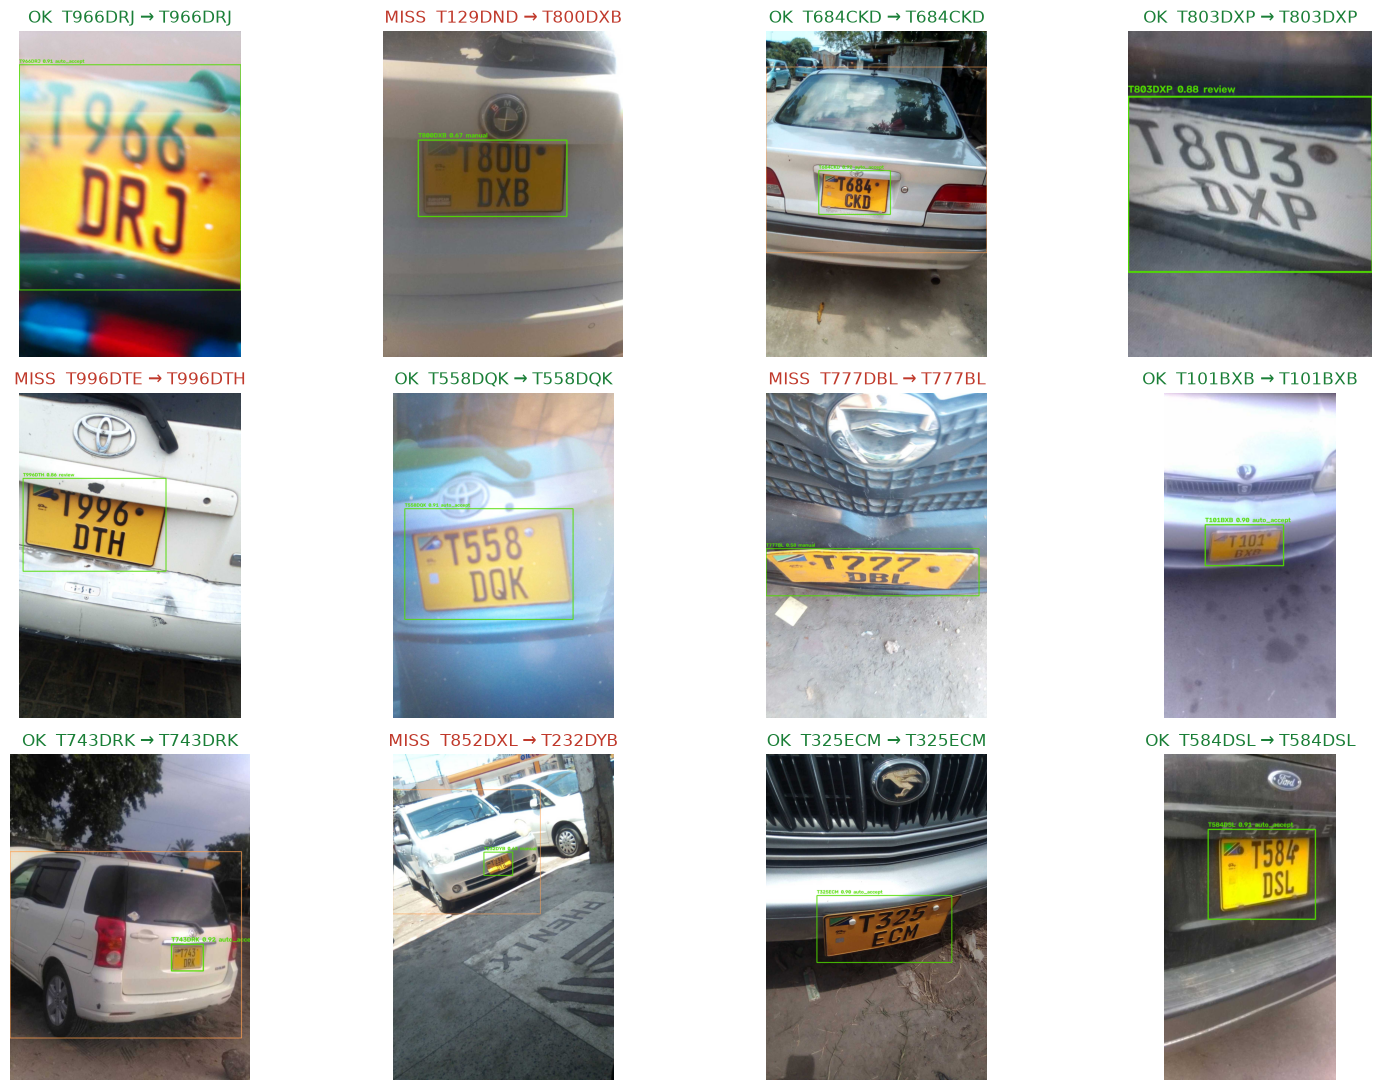

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, (ok, path, truth, pred, conf, resp, img) in zip(axes.ravel(), rows):
    vis = annotate(img, resp)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{'OK' if ok else 'MISS'}  {truth} → {pred or '—'}", color=("#1a7f37" if ok else "#c0392b"))
    ax.axis("off")
plt.tight_layout()
plt.show()

## Optional: hit the running API

The live server is on port **8081** (8080 is Open WebUI).

In [6]:
import httpx

API = "http://127.0.0.1:8081"
print(httpx.get(f"{API}/health", timeout=5).json())
print(httpx.get(f"{API}/version", timeout=5).json())

with IMAGE.open("rb") as fh:
    api_resp = httpx.post(f"{API}/v1/plate-reader", files={"upload": (IMAGE.name, fh, "image/jpeg")}, timeout=30)
print(json.dumps(api_resp.json(), indent=2))

HTTP Request: GET http://127.0.0.1:8081/health "HTTP/1.1 200 OK"
HTTP Request: GET http://127.0.0.1:8081/version "HTTP/1.1 200 OK"
HTTP Request: POST http://127.0.0.1:8081/v1/plate-reader "HTTP/1.1 200 OK"


{'status': 'ok', 'detail': 'all models loaded'}
{'package_version': '1.2.0', 'model_version': 'tz-alpr-1.2.0', 'components': {'vehicle_detector': 'coco-yolov8n', 'plate_detector': 'v1', 'ocr': 'v1', 'country_rules': 'tz-2024.1', 'plate_detector_backend': 'yolo', 'vehicle_detector_backend': 'yolo', 'ocr_backend': 'torch'}}
{
  "processing_time_ms": 43,
  "model_version": "tz-alpr-1.2.0",
  "results": [
    {
      "plate": "T336CAG",
      "raw_text": "T 336 CAG",
      "raw_ocr": "T336CAG",
      "normalized_text": "T336CAG",
      "confidence": 0.8784,
      "confidence_breakdown": {
        "vehicle_confidence": 0.0,
        "plate_detection_confidence": 0.8245,
        "ocr_confidence": 0.8802,
        "plate_validation_confidence": 0.92,
        "final_confidence": 0.8784
      },
      "plate_bbox": {
        "x": 271,
        "y": 401,
        "width": 449,
        "height": 288
      },
      "plate_bbox_in_vehicle": null,
      "plate_quad": null,
      "vehicle": {
        "ty

## Tuk-tuk (bajaji) and motorcycle

Tanzanian bajaji and bikes share `MC###ABC` plates. The vehicle detector is COCO YOLOv8n — it has **no tuk-tuk class**, so `vehicle.type` is often `unknown` or `truck`. Plate type should still come back `MOTORCYCLE`.

OK    tuktuk            MC736DSS   -> MC736DSS    veh=unknown   p=0.90  MC736DSS-01250f87328111ee9793b7b50dcfc96f.jpg
OK    tuktuk            MC298DCH   -> MC298DCH    veh=truck     p=0.92  MC298DCH-0229179e62a411eeb9c1813d444f6004.jpg
OK    tuktuk            MC951BSZ   -> MC951BSZ    veh=unknown   p=0.87  MC951BSZ-01cbb30aa0dc11ee8b9c07ba6006837f.jpg
MISS  tuktuk            MC102BXK   -> —           veh=none      p=0.00  MC102BXK-76969697432711ee91939dc1ff488d4e.jpg
MISS  tuktuk            MC103DJJ   -> —           veh=none      p=0.00  MC103DJJ-8699a52fb06b11efbcc87d63333db7aa.jpg
OK    tuktuk            MC108DPX   -> MC108DPX    veh=unknown   p=0.89  MC108DPX-ee4ecdf12ecd11efbb66675009997ca8.jpg
MISS  tuktuk            MC140CTM   -> MC731EBX    veh=truck     p=0.92  MC140CTM-00fa00819bd411ee8b9cef158425252d.jpg
MISS  motorcycle/hard   MC101AAA   -> T773DQD     veh=unknown   p=0.50  MC101AAA-00532171ed8311eda557070b20e05f65.jpg
MISS  motorcycle?       MC115BKK   -> T118BKK     veh=un

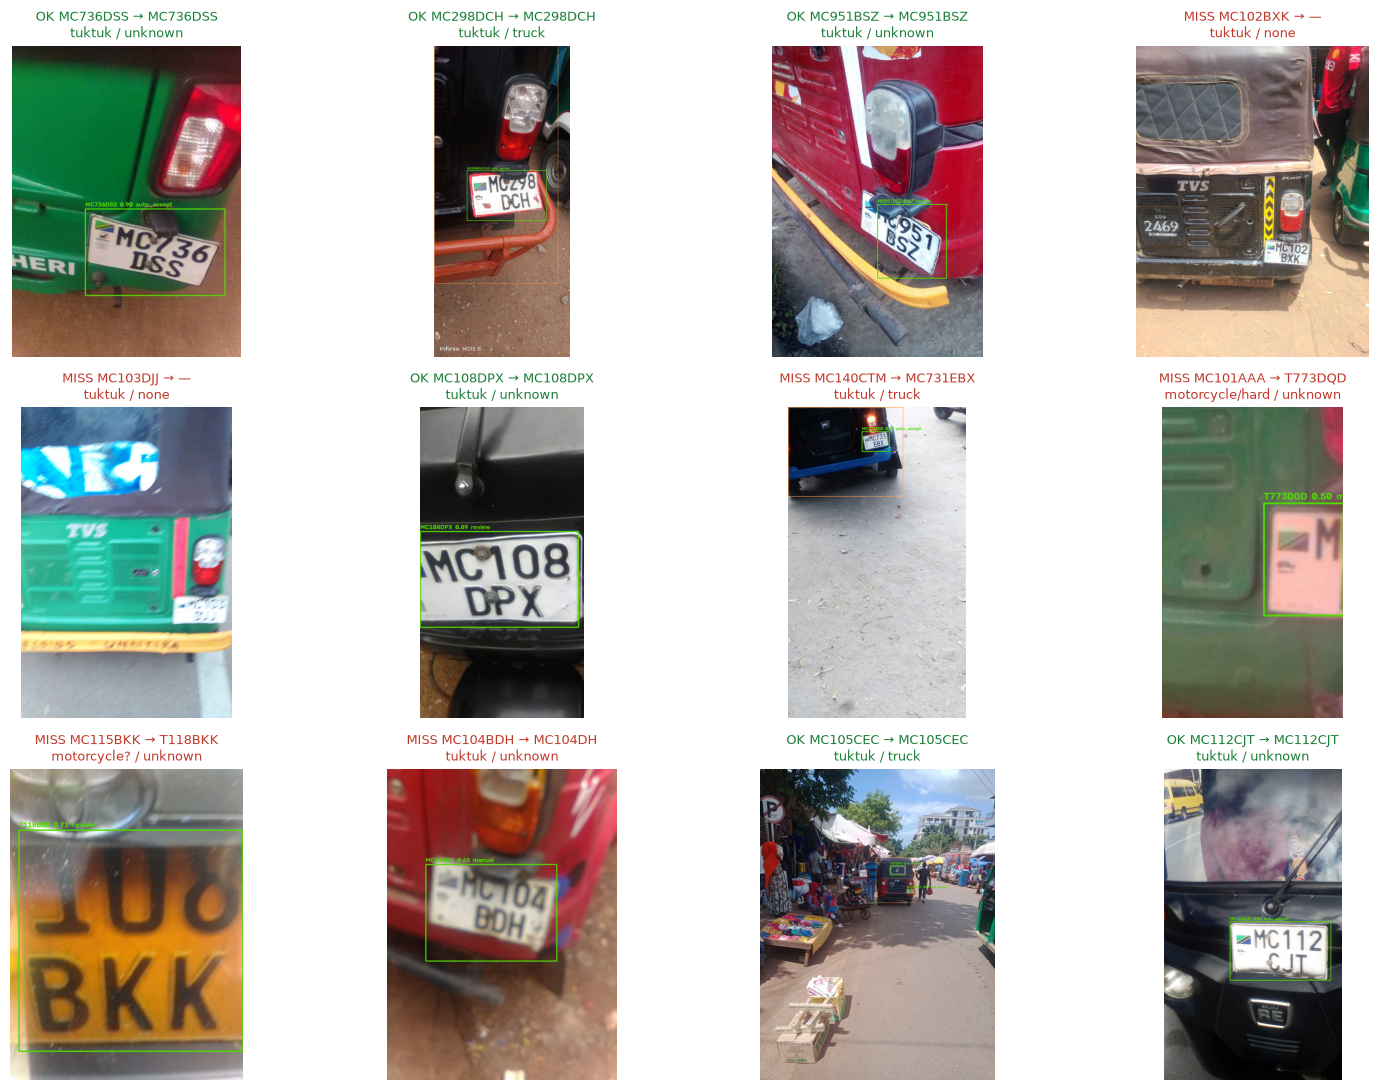

In [7]:
CASES = [
    ("tuktuk", "MC736DSS-01250f87328111ee9793b7b50dcfc96f.jpg", "MC736DSS"),
    ("tuktuk", "MC298DCH-0229179e62a411eeb9c1813d444f6004.jpg", "MC298DCH"),
    ("tuktuk", "MC951BSZ-01cbb30aa0dc11ee8b9c07ba6006837f.jpg", "MC951BSZ"),
    ("tuktuk", "MC102BXK-76969697432711ee91939dc1ff488d4e.jpg", "MC102BXK"),
    ("tuktuk", "MC103DJJ-8699a52fb06b11efbcc87d63333db7aa.jpg", "MC103DJJ"),
    ("tuktuk", "MC108DPX-ee4ecdf12ecd11efbb66675009997ca8.jpg", "MC108DPX"),
    ("tuktuk", "MC140CTM-00fa00819bd411ee8b9cef158425252d.jpg", "MC140CTM"),
    ("motorcycle/hard", "MC101AAA-00532171ed8311eda557070b20e05f65.jpg", "MC101AAA"),
    ("motorcycle?", "MC115BKK-1926bd8ddaad11eda2965bac82211625.jpg", "MC115BKK"),
    ("tuktuk", "MC104BDH-a2508010885b11ee9347f3ba13796769.jpg", "MC104BDH"),
    ("tuktuk", "MC105CEC-58bd80c4142e11ef8ea90d6b3ce46dc6.jpg", "MC105CEC"),
    ("tuktuk", "MC112CJT-8012ffc3e32f11edac21adca9fc17ddb.jpg", "MC112CJT"),
]

mc_rows = []
for kind, name, truth in CASES:
    path = images_dir / name
    img = imread(path)
    resp = pipeline.read_image(img)
    pred = resp.results[0].plate if resp.results else ""
    conf = resp.results[0].confidence if resp.results else 0.0
    veh = resp.results[0].vehicle.type if resp.results else "none"
    ok = pred == truth
    mc_rows.append((ok, kind, path, truth, pred, conf, veh, resp, img))
    print(f"{'OK' if ok else 'MISS':4}  {kind:16}  {truth:10} -> {pred or '—':10}  veh={veh:8}  p={conf:.2f}  {name}")

hits = sum(1 for ok, *_ in mc_rows if ok)
print(f"\nexact match  {hits}/{len(mc_rows)}  ({hits / len(mc_rows):.0%})")

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, (ok, kind, path, truth, pred, conf, veh, resp, img) in zip(axes.ravel(), mc_rows):
    vis = annotate(img, resp) if resp.results else img
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{'OK' if ok else 'MISS'} {truth} → {pred or '—'}\n{kind} / {veh}", color=("#1a7f37" if ok else "#c0392b"), fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()